# CosmicShearSNREvaluator demo

This notebook demonstrates the `CosmicShearSNREvaluator` RAIL stage.
It:
1. Creates a 4-bin tomographic n(z) qp ensemble with Gaussian bins
2. Saves both the ensemble and the nz_summary (neff) to disk
3. Runs the stage to compute the cosmic shear SNR
4. Shows the results

In [1]:
import warnings
warnings.filterwarnings('ignore')

from collections import OrderedDict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qp
import tables_io

from rail.evaluation.metrics.cosmic_shear_snr import CosmicShearSNREvaluator

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

## 1  Create the tomographic n(z) ensemble

Four Gaussian bins centred at z = 0.45, 0.75, 1.05, 1.35 with σ = 0.15.
The qp ensemble has **one row per bin** (npdf = 4).

In [2]:
# Redshift grid
z = np.linspace(0.0, 3.0, 301)

# Bin centres and width
z_means = [0.45, 0.75, 1.05, 1.35]
sigma    = 0.15
n_bins   = len(z_means)

# Build normalised Gaussian n(z) for each bin  →  shape (n_bins, n_z)
yvals = np.array([
    np.exp(-0.5 * ((z - m) / sigma) ** 2)
    for m in z_means
])
for i in range(n_bins):
    yvals[i] /= np.trapezoid(yvals[i], z)

# Create qp ensemble: one row per tomographic bin
nz_ens = qp.Ensemble(qp.interp, data={'xvals': z, 'yvals': yvals})
print(f'npdf = {nz_ens.npdf}  (one row per tomo bin)')
print(f'xvals shape: {nz_ens.dist.xvals.shape}')
print(f'yvals shape: {nz_ens.dist.yvals.shape}')

npdf = 4  (one row per tomo bin)
xvals shape: (301,)
yvals shape: (4, 301)


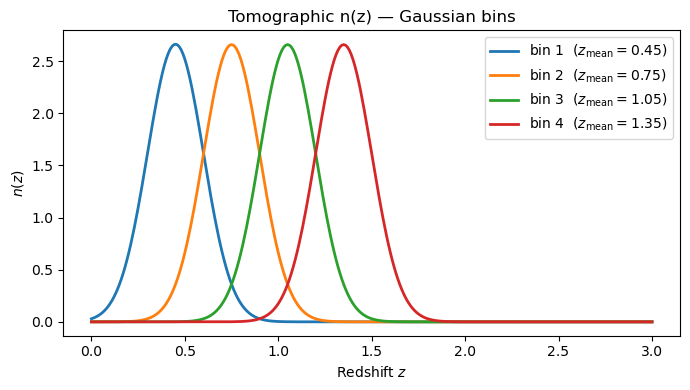

In [3]:
# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['C0', 'C1', 'C2', 'C3']
for b in range(n_bins):
    ax.plot(z, nz_ens.dist.yvals[b], color=colors[b], lw=2,
            label=rf'bin {b+1}  ($z_{{\rm mean}}={z_means[b]:.2f}$)')
ax.set(xlabel='Redshift $z$', ylabel='$n(z)$',
       title='Tomographic n(z) — Gaussian bins')
ax.legend()
plt.tight_layout()

## 2  Save the ensemble and nz_summary to disk

In [4]:
NZ_ENS_FILE     = str(DATA_DIR / 'tomo_nz.hdf5')
NZ_SUMMARY_FILE = str(DATA_DIR / 'nz_summary.hdf5')

# Save the qp ensemble
nz_ens.write_to(NZ_ENS_FILE)
print(f'Saved n(z) ensemble  →  {NZ_ENS_FILE}')

Saved n(z) ensemble  →  data/tomo_nz.hdf5


In [5]:
# Save nz_summary: effective number density per bin [arcmin^-2]
neff = np.array([5.0, 5.0, 5.0, 5.0])

nz_summary = OrderedDict([
    ('nz_summary', pd.DataFrame({'neff': neff}))
])
tables_io.write(nz_summary, NZ_SUMMARY_FILE)
print(f'Saved nz_summary      →  {NZ_SUMMARY_FILE}')

# Verify round-trip
loaded = tables_io.read(NZ_SUMMARY_FILE)
print(f"  neff read back: {np.asarray(loaded['nz_summary']['neff'])}")

Saved nz_summary      →  data/nz_summary.hdf5
  neff read back: [5. 5. 5. 5.]


## 3  Run the CosmicShearSNREvaluator

Survey parameters:
- **f_sky** = 0.01  (≈ 413 deg², similar to HSC Y3)
- **σ_e** = 0.26   (per-component ellipticity dispersion)
- Scale cuts: ℓ ∈ [300, 1800]

In [6]:
OUTPUT_FILE = str(DATA_DIR / 'snr_results.hdf5')

stage = CosmicShearSNREvaluator.make_stage(
    name     = 'cssnr_demo',
    f_sky    = 0.01,
    sigma_e  = 0.26,
    ell_min  = 100.0,
    ell_max  = 15800.0,
    n_ell    = 17,
    ell_min_cut = 300.0,
    ell_max_cut = 1800.0,
    output   = OUTPUT_FILE,
)
print(stage)

In [7]:
# Pass the in-memory objects directly
nz_summary_data = tables_io.read(NZ_SUMMARY_FILE)
result_handle   = stage.evaluate(nz_ens, nz_summary_data)

summary  = result_handle.data['summary']
pairs_df = result_handle.data['pairs']

total_snr = float(summary['total_snr'].iloc[0])
print(f'\nTotal cosmic shear SNR = {total_snr:.2f}')

Inserting handle into data store.  input: None, cssnr_demo
Inserting handle into data store.  nz_summary: None, cssnr_demo


Inserting handle into data store.  output_cssnr_demo: data/inprogress_snr_results.hdf5, cssnr_demo

Total cosmic shear SNR = 66.60


## 4  Inspect and plot the results

In [8]:
print('Summary table:')
display(summary[['total_snr', 'ell_min_cut', 'ell_max_cut']])

print('\nPer-pair SNR:')
display(pairs_df[['pair_i', 'pair_j', 'snr_per_pair']].to_string(index=False))

Summary table:


,total_snr,ell_min_cut,ell_max_cut
0,66.599808,300.0,1800.0



Per-pair SNR:


' pair_i  pair_j  snr_per_pair\n      0       0      9.450890\n      0       1     18.609010\n      0       2     19.956816\n      0       3     19.935840\n      1       1     22.421609\n      1       2     36.278596\n      1       3     37.998218\n      2       2     34.533603\n      2       3     50.960672\n      3       3     44.494318'

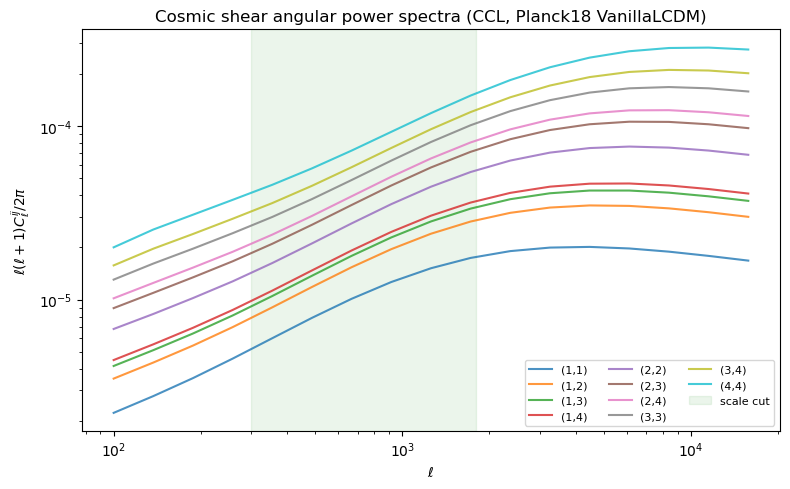

In [9]:
# Recover the ell grid from the summary table
n_ell = 17
ells  = np.array([float(summary[f'ell_{i}'].iloc[0]) for i in range(n_ell)])

# Recover C_ell for each pair
cls = np.column_stack([
    pairs_df[f'cls_ell_{i}'].values for i in range(n_ell)
])

fig, ax = plt.subplots(figsize=(8, 5))
pair_labels = [
    f"({int(row.pair_i)+1},{int(row.pair_j)+1})"
    for row in pairs_df.itertuples()
]
for p_idx, (cls_p, label) in enumerate(zip(cls, pair_labels)):
    ax.loglog(ells, ells * (ells + 1) / (2 * np.pi) * cls_p,
              lw=1.5, alpha=0.8, label=label)
ax.axvspan(300, 1800, alpha=0.08, color='green', label='scale cut')
ax.set(xlabel=r'$\ell$',
       ylabel=r'$\ell(\ell+1)C_\ell^{ij} / 2\pi$',
       title='Cosmic shear angular power spectra (CCL, Planck18 VanillaLCDM)')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()

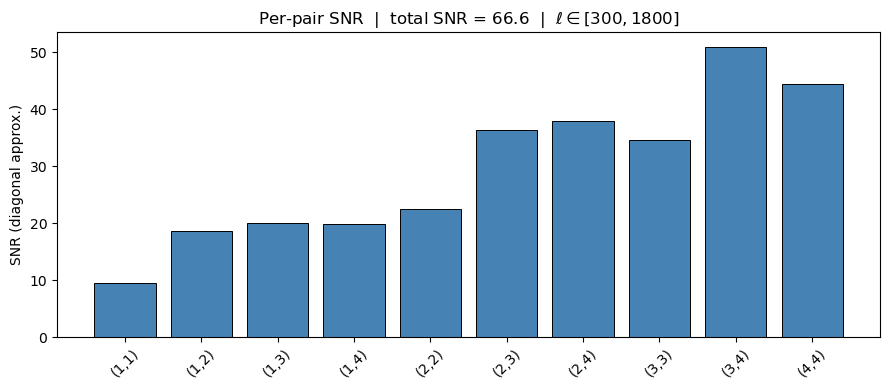

In [10]:
# Per-pair SNR bar chart
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(pair_labels, pairs_df['snr_per_pair'], color='steelblue',
       edgecolor='k', linewidth=0.7)
ax.set(ylabel='SNR (diagonal approx.)',
       title=f'Per-pair SNR  |  total SNR = {total_snr:.1f}  |  '
             rf'$\ell \in [300, 1800]$')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## 5  Vary f_sky and observe the SNR scaling

For a Gaussian covariance the SNR scales as $\sqrt{f_{\rm sky}}$.

Inserting handle into data store.  input: None, cssnr_fsky_0.005
Inserting handle into data store.  nz_summary: None, cssnr_fsky_0.005


Inserting handle into data store.  output_cssnr_fsky_0.005: data/inprogress_snr_fsky_0.005.hdf5, cssnr_fsky_0.005
Inserting handle into data store.  input: None, cssnr_fsky_0.010
Inserting handle into data store.  nz_summary: None, cssnr_fsky_0.010


Inserting handle into data store.  output_cssnr_fsky_0.010: data/inprogress_snr_fsky_0.010.hdf5, cssnr_fsky_0.010
Inserting handle into data store.  input: None, cssnr_fsky_0.020
Inserting handle into data store.  nz_summary: None, cssnr_fsky_0.020


Inserting handle into data store.  output_cssnr_fsky_0.020: data/inprogress_snr_fsky_0.020.hdf5, cssnr_fsky_0.020
Inserting handle into data store.  input: None, cssnr_fsky_0.050
Inserting handle into data store.  nz_summary: None, cssnr_fsky_0.050


Inserting handle into data store.  output_cssnr_fsky_0.050: data/inprogress_snr_fsky_0.050.hdf5, cssnr_fsky_0.050
Inserting handle into data store.  input: None, cssnr_fsky_0.100
Inserting handle into data store.  nz_summary: None, cssnr_fsky_0.100


Inserting handle into data store.  output_cssnr_fsky_0.100: data/inprogress_snr_fsky_0.100.hdf5, cssnr_fsky_0.100
Inserting handle into data store.  input: None, cssnr_fsky_0.200
Inserting handle into data store.  nz_summary: None, cssnr_fsky_0.200


Inserting handle into data store.  output_cssnr_fsky_0.200: data/inprogress_snr_fsky_0.200.hdf5, cssnr_fsky_0.200


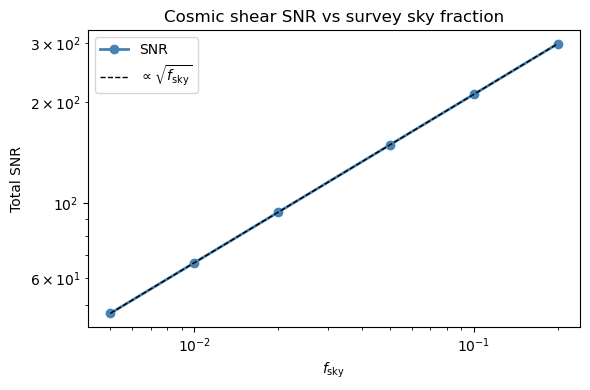

In [11]:
f_sky_values = [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]
snr_values   = []

for f in f_sky_values:
    s = CosmicShearSNREvaluator.make_stage(
        name=f'cssnr_fsky_{f:.3f}',
        f_sky=f, sigma_e=0.26,
        ell_min=100.0, ell_max=15800.0, n_ell=17,
        ell_min_cut=300.0, ell_max_cut=1800.0,
        output=str(DATA_DIR / f'snr_fsky_{f:.3f}.hdf5'),
    )
    snr_values.append(
        float(s.evaluate(nz_ens, nz_summary_data).data['summary']['total_snr'].iloc[0])
    )

fig, ax = plt.subplots(figsize=(6, 4))
f_arr   = np.array(f_sky_values)
snr_arr = np.array(snr_values)
ax.loglog(f_arr, snr_arr, 'o-', color='steelblue', lw=2, label='SNR')
# overplot sqrt scaling anchored at reference point
ref = snr_arr[1]
ax.loglog(f_arr, ref * np.sqrt(f_arr / f_arr[1]), '--k', lw=1,
          label=r'$\propto \sqrt{f_{\rm sky}}$')
ax.set(xlabel=r'$f_{\rm sky}$', ylabel='Total SNR',
       title='Cosmic shear SNR vs survey sky fraction')
ax.legend()
plt.tight_layout()